In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_rms(data):
	data = np.array(data)
	data = data - (sum(data)/len(data))
	s = data**2
	ms = sum(s)/len(s)
	rms = np.sqrt(ms)
	return rms

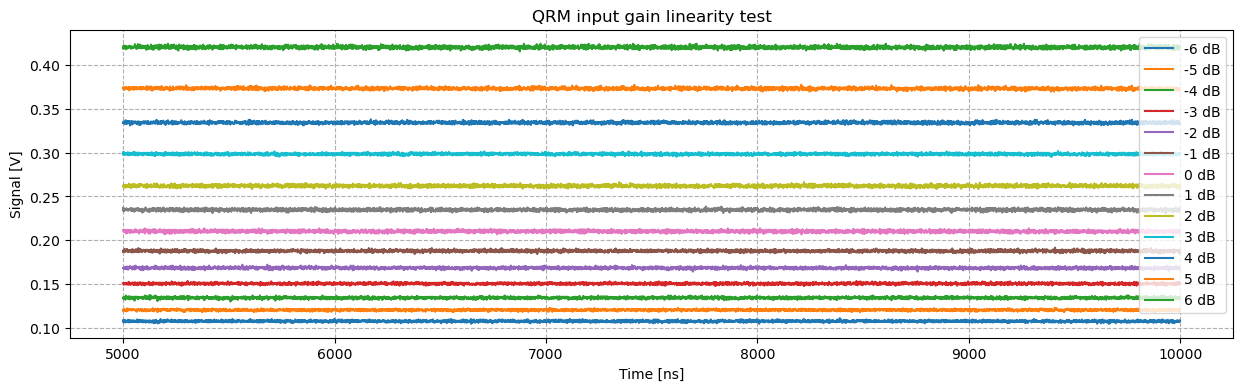

In [3]:
test_data = np.loadtxt(r"0 dB.txt")
t = np.arange(0, len(test_data))

hi = 10000
lo = 5000

gains = np.arange(-6, 7, 1)
datas = []
for gain in gains:
	datas += [np.loadtxt(rf"{gain} dB.txt")]

fig, ax = plt.subplots(1, 1, figsize = (15, 4))

for i in range(len(gains)):
	ax.plot(t[lo:hi], datas[i][lo:hi], label = f"{gains[i]} dB")

ax.set_ylabel("Signal [V]")
ax.set_xlabel("Time [ns]")
ax.set_title("QRM input gain linearity test")
ax.grid(ls = "--")
plt.legend()
plt.show()

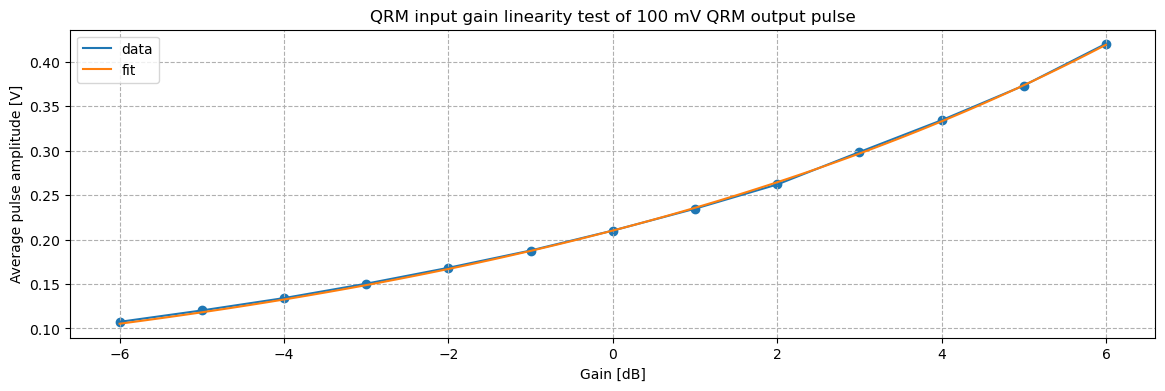

In [12]:
hi = 10000
lo = 5000
gains = np.arange(-6, 7, 1)
avgs = []
for gain in gains:
	data = np.loadtxt(rf"{gain} dB.txt")[lo:hi]
	avgs += [sum(data)/len(data)]

# Making a fit line for the model
fit_index = 6
v_i = avgs[fit_index]/(10**(gains[fit_index]/20))

gains_fit = np.linspace(-6, 6, 100)
amps_fit = v_i*(10**(gains_fit/20))

fig, ax = plt.subplots(1, 1, figsize = (14, 4))
ax.scatter(gains, avgs)
ax.plot(gains, avgs, label = "data")
ax.plot(gains_fit, amps_fit, label = "fit")
ax.set_ylabel("Average pulse amplitude [V]")
ax.set_xlabel("Gain [dB]")
ax.set_title("QRM input gain linearity test of 100 mV QRM output pulse") # 100 mV verified with oscilloscope
ax.grid(ls = "--")
plt.legend()
plt.show()

In [5]:
ratio_indeces = np.arange(0, 7, 1)
ratios = []

for i in ratio_indeces:
	ratios += [round((avgs[i + 6] / avgs[i]), 3)]

print(ratios)

[1.956, 1.952, 1.953, 1.985, 1.987, 1.989, 2.001]


### Seeing how the RMS noise grows with gain

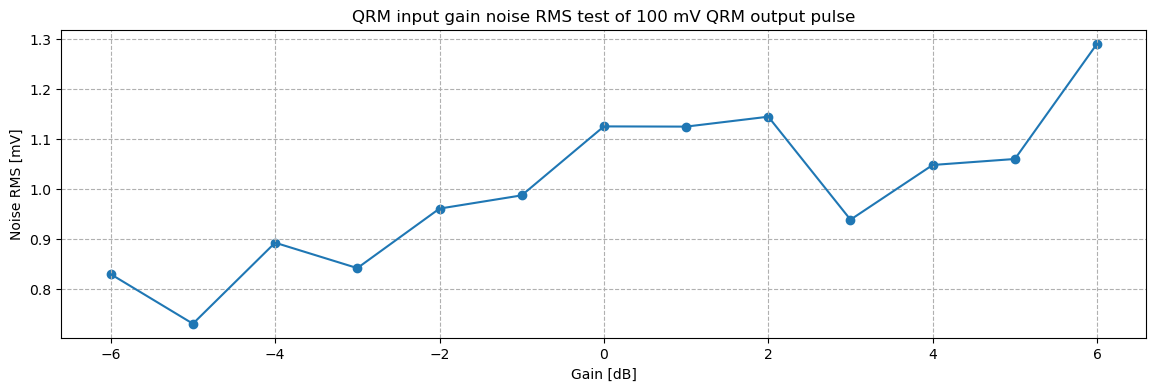

In [17]:
rmss = []
for i in range(len(gains)):
	rmss += [get_rms(datas[i][lo:hi])]

rmss = np.array(rmss)
fig, ax = plt.subplots(1, 1, figsize = (14, 4))
ax.plot(gains, rmss*1000)
ax.scatter(gains, rmss*1000)
ax.set_ylabel("Noise RMS [mV]")
ax.set_xlabel("Gain [dB]")
ax.set_title("QRM input gain noise RMS test of 100 mV QRM output pulse")
ax.grid(ls = "--")
plt.show()